# CNN with MNIST dataset

Based on a notebook by Chanseok Kang


In [1]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

## CNN model with sequential API
CNN model:
![CNN](https://github.com/goodboychan/goodboychan.github.io/blob/main/_notebooks/image/CNN_MNIST.png?raw=1)

Three 3x3 2D convolution layers, each followed by a 2x2 max-pooling; then a fully-connected layer as an output layer for classification. In each convolution layer, stride will be 1, and padding will be `same` (that is, we will use half padding -- see Monday's notebook wk13-2). And in max-pooling layer, stride will be 2.

### Hyperparameters

In [3]:
learning_rate = 0.001
training_epochs = 15
batch_size = 128

And for the tracking model training, it is helpful to build checkpoint while training the model, so when we the model training is failed due to unexpected reason, we can re-train it with checkpoint.

In [4]:
import os

cur_dir = os.getcwd()
checkpoint_dir = os.path.join(cur_dir, 'checkpoints', 'mnist_cnn_seq')
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_dir, 'mnist_cnn_seq')

### Data Preprocessing
Before model implementation, data-preprocess is often required, often involving image normalizing and reshaping.

Note that, the label of each data is class label. So to use it in Neural network model, it needs be "binarized" (using the term from sklearn, or **one-hot** encoding -- tf.keras implements this as `to_categorical` for one-hot encoding.

In [5]:
data = tf.keras.datasets.mnist.load_data()

In [6]:
# One-hot encoding
from tensorflow.keras.utils import to_categorical

# MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()


In [7]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

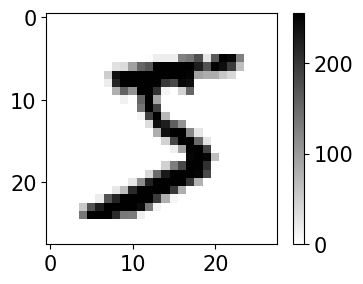

In [8]:
plt.figure(figsize=(4, 3))
plt.imshow(X_train[0], cmap='binary')
plt.colorbar()

## Breakout Exercise

Write a function to plot 30 (in 5x6 format) images from the training sample and 30 from the testing sample.

In [9]:
X_train[0].max(), X_train[0].min()

(np.uint8(255), np.uint8(0))

In [10]:
# Normalization
# May use different normalization -- say mean = 0, std = 1
X_train = X_train.astype(np.float32) / 255.
X_test = X_test.astype(np.float32) / 255.

print('Before dim expansion, X_train.shape', X_train.shape)


Before dim expansion, X_train.shape (60000, 28, 28)


In [11]:
# Convert it to 4D array (or we can use np.expand_dims for dimension expansion)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print('After dim expansion, X_train.shape', X_train.shape)


After dim expansion, X_train.shape (60000, 28, 28, 1)


In [12]:
print('Before one-hot encoding:', y_train[0])

# one-hot encoding --- this is the same as binarizer in sklearn
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print('After one-hot encoding:', y_train[0])


Before one-hot encoding: 5
After one-hot encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [13]:
'''
Build dataset pipeline
Ref: https://www.tensorflow.org/api_docs/python/tf/data/Dataset

This dataset fills a buffer with buffer_size elements, then randomly samples elements from this buffer,
replacing the selected elements with new elements. For perfect shuffling, a buffer size greater than or
equal to the full size of the dataset is required.

For instance, if your dataset contains 10,000 elements but buffer_size is set to 1,000, then shuffle will
initially select a random element from only the first 1,000 elements in the buffer. Once an element is
selected, its space in the buffer is replaced by the next (i.e. 1,001-st) element, maintaining the 1,000
element buffer.

'''

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(buffer_size=100000).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

In [14]:
type(train_ds), len(train_ds)

(tensorflow.python.data.ops.batch_op._BatchDataset, 469)

In [15]:
n = 0
for images, labels in train_ds:
  if n < 5 or n > 465:
    print(n, images.shape, labels.shape)
  n += 1

0 (128, 28, 28, 1) (128, 10)
1 (128, 28, 28, 1) (128, 10)
2 (128, 28, 28, 1) (128, 10)
3 (128, 28, 28, 1) (128, 10)
4 (128, 28, 28, 1) (128, 10)
466 (128, 28, 28, 1) (128, 10)
467 (128, 28, 28, 1) (128, 10)
468 (96, 28, 28, 1) (96, 10)


In [16]:
train_ds.__dict__

{'_input_dataset': <_ShuffleDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float64, name=None))>,
 '_batch_size': <tf.Tensor: shape=(), dtype=int64, numpy=128>,
 '_drop_remainder': <tf.Tensor: shape=(), dtype=bool, numpy=False>,
 '_structure': (TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 10), dtype=tf.float64, name=None)),
 '_name': None,
 '_variant_tensor_attr': <tf.Tensor: shape=(), dtype=variant, value=<BatchDatasetV2Op(128)::Dataset>>,
 '_graph_attr': <tensorflow.python.framework.ops.Graph at 0x128e00b40>,
 '_options_attr': <tensorflow.python.data.ops.options.Options at 0x128e65130>}

In [17]:
train_ds._batch_size

<tf.Tensor: shape=(), dtype=int64, numpy=128>

In [18]:
# contains images and classes
train_ds.element_spec

(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 10), dtype=tf.float64, name=None))

### Build model with Sequential API
Building model with Sequential API is similar with previous example. The difference is that Sequential API pre-build the model skeleton, then add each specific layers. In this code, we will build one API to build whole models.

In [19]:
def create_model():
    model = tf.keras.Sequential(name='CNN_Sequential')
    model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation=tf.keras.activations.relu,
                                     padding='same', input_shape=(28, 28, 1)))
    model.add(tf.keras.layers.MaxPool2D(padding='same'))
    model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation=tf.keras.activations.relu,
                                     padding='same'))
    model.add(tf.keras.layers.MaxPool2D(padding='same'))
    model.add(tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation=tf.keras.activations.relu,
                                     padding='same'))
    model.add(tf.keras.layers.MaxPool2D(padding='same'))
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(256, activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(10))
    return model

# Create model -- note the 0th dim showing None b/c it doesn't know the sample size yet
model = create_model()
model.summary()

/Users/alexanderflores/Library/Python/3.12/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,786 (2.36 MB)

 Trainable params: 619,786 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Note that, in Sequential model, each previous layers node is connected with next layers node automatically, and ll we need to do is to input the data in the model, then output will be generated from the whole model.

### Loss Function and Gradient
Same as MLP, we need to define loss function and use gradient descent for finding minimum loss.

Gradient Calculation and Autodiff (more discussion on Wednesday)

Code resource: https://www.tensorflow.org/guide/autodiff

In [20]:
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
  y = x**2

# dy = 2x * dx
dy_dx = tape.gradient(y, x)
dy_dx.numpy()

np.float32(6.0)

Matrix multiplication -- alternative notation: works for numpy and tf objects

In [21]:
A = np.array([[1, 2], [3, 4]])
v = np.array([5, 6])
A @ v

array([17, 39])

In [22]:
'''
gradient for Simple perceptron like structure
'''

w = tf.Variable(tf.random.normal((3, 2)), name='w')
b = tf.Variable(tf.zeros(2, dtype=tf.float32), name='b')
x = [[1., 2., 3.]]

y = [1, 0]
with tf.GradientTape(persistent=True) as tape:
  z = x @ w + b
  loss = tf.reduce_mean((y - z)**2)

z, y, loss

(<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[-2.151133 ,  1.0454445]], dtype=float32)>,
 [1, 0],
 <tf.Tensor: shape=(), dtype=float32, numpy=5.511297225952148>)

In [23]:
'''
Note the use of tape (which binds all the different parts together for the derivative operation)
'''

[dl_dw, dl_db] = tape.gradient(loss, [w, b])

print(w.shape)
print(dl_dw.shape)
dl_dw, dl_db

(3, 2)
(3, 2)


(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-3.151133 ,  1.0454445],
        [-6.302266 ,  2.090889 ],
        [-9.4534   ,  3.1363335]], dtype=float32)>,
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([-3.151133 ,  1.0454445], dtype=float32)>)

In [24]:
# Loss function
def loss_fn(model, images, labels):
    logits = model(images, training=True)
    loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=logits, labels=labels))
    return loss

# Gradient Function
def grad(model, images, labels):
    with tf.GradientTape() as tape:
        loss = loss_fn(model, images, labels)
    return tape.gradient(loss, model.trainable_variables) # the gradient: d(loss) / d(trainable_variables)

In [49]:
import tensorflow as tf
a = np.random.rand(0)
print(a)

tf.argmax(a), tf.argmax(a).numpy()

[]


InvalidArgumentError: {{function_node __wrapped__ArgMax_device_/job:localhost/replica:0/task:0/device:CPU:0}} Reduction axis 0 is empty in shape [0] [Op:ArgMax] name: 

### Optimizer and Evaluation
For finding optimum value, we will use "Adam" Optimizer with predifined learning_rate. Also, we need to define evaluation function so that we can check the performance (or accuracy of model).

One more thing, We already mention that checkpoint is required for tracking history. So we will define it here.


In [25]:
'''
Undestanding tf.argmax():

Predictions for 3 images with "z" values for each of the 10 classes (before softmax = e^z_i /sum(e^z_j)),
or logits

'''
# the "z", then compare z with the ground truth (or target, or label, or "y")
pred = np.array([[31, 23,  4, 24, 27, 34, 18,  3, 25,  0],
                [28, 14, 33, 22, 20,  8, 13, 30, 21, 19],
                [16,  1, 26, 32,  2, 29, 17, 12,  5, 11]])

tf.argmax(pred, axis=0), tf.argmax(pred, axis=1)

(<tf.Tensor: shape=(10,), dtype=int64, numpy=array([0, 0, 1, 2, 0, 0, 0, 1, 0, 1])>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([5, 2, 3])>)

In [26]:
# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Evaluation function
def evaluate(model, images, labels):
    logits = model(images, training=False)
    correct_predict = tf.equal(tf.argmax(logits, axis=1), tf.argmax(labels, axis=1))
    accuracy = tf.reduce_mean(tf.cast(correct_predict, tf.float32))
    return accuracy

# Checkpoint
checkpoint = tf.train.Checkpoint(cnn=model)

### Training and Validation
Finally, we can train model with our training dataset. And also we need to check the performance while training the model, so after train the model in each epoch, we will also evaluate the model.

In [27]:
from tqdm import tqdm
import time

for i in tqdm(range(50)):
    time.sleep(0.1)

100%|██████████| 50/50 [00:05<00:00,  9.57it/s]


In [28]:
for e in range(training_epochs):

    avg_loss = 0.
    avg_train_acc = 0.
    avg_test_acc = 0.
    train_step = 0
    test_step = 0

    for images, labels in train_ds:
        grads = grad(model, images, labels)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        loss = loss_fn(model, images, labels)
        acc = evaluate(model, images, labels)
        avg_loss = avg_loss + loss
        avg_train_acc = avg_train_acc + acc
        train_step += 1
    avg_loss = avg_loss / train_step
    avg_train_acc = avg_train_acc / train_step

    for images, labels in test_ds:
        acc = evaluate(model, images, labels)
        avg_test_acc = avg_test_acc + acc
        test_step += 1
    avg_test_acc = avg_test_acc / test_step

    print("Epoch: {}".format(e + 1),
          "loss: {:.8f}".format(avg_loss),
          "train acc: {:.4f}".format(avg_train_acc),
          "test acc: {:.4f}".format(avg_test_acc))

    checkpoint.save(file_prefix=checkpoint_prefix)

Epoch: 1 loss: 0.19364685 train acc: 0.9530 test acc: 0.9843
Epoch: 2 loss: 0.05030904 train acc: 0.9888 test acc: 0.9911
Epoch: 3 loss: 0.03499210 train acc: 0.9925 test acc: 0.9903
Epoch: 4 loss: 0.02651722 train acc: 0.9945 test acc: 0.9928
Epoch: 5 loss: 0.02120873 train acc: 0.9955 test acc: 0.9925
Epoch: 6 loss: 0.01762016 train acc: 0.9967 test acc: 0.9936
Epoch: 7 loss: 0.01440187 train acc: 0.9977 test acc: 0.9942
Epoch: 8 loss: 0.01224778 train acc: 0.9981 test acc: 0.9927
Epoch: 9 loss: 0.01049008 train acc: 0.9985 test acc: 0.9932
Epoch: 10 loss: 0.00982900 train acc: 0.9986 test acc: 0.9935
Epoch: 11 loss: 0.00779477 train acc: 0.9990 test acc: 0.9942
Epoch: 12 loss: 0.00630095 train acc: 0.9993 test acc: 0.9928
Epoch: 13 loss: 0.00684435 train acc: 0.9991 test acc: 0.9926
Epoch: 14 loss: 0.00647685 train acc: 0.9993 test acc: 0.9918
Epoch: 15 loss: 0.00524633 train acc: 0.9995 test acc: 0.9928


## Breakout Exercise

- Remove the printing statements, and just show the progress bar
- Save the history of training and testing accuracies and the loss history
- Plot the accuricies for training and testing samples vs. epochs on one subplot, and label the two curves appropriately
- Plot the loss vs epochs on another subpplot.  
- The two subplots should be side by side.
- Label the axes of both plots appropriately
- When you're experimenting, set training_epochs = 2 (saves you time!)

In [38]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

## Breakout Exercise:

1. Make predictions for the first 30 images in the testing set
2. Find the first instance of an incorrectly classified image, show it and use red text as its title -- showing the label and the classification.

In [39]:
'''
Note the shape of X_test[0] vs. X_test[:1]

model.predict() will not work for the former!!

You have to use [..., tf.newaxis] to add the dummy dimension to X_test[0]
'''
X_test[0].shape, X_test[:1].shape

((28, 28, 1), (1, 28, 28, 1))

In [40]:
print(tf.argmax((model.predict(X_test[:1])), axis=1))

if not tf.argmax(y_test[:1], axis=1) == tf.argmax((model.predict(X_test[:1])), axis=1).numpy():
  print('true')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
tf.Tensor([7], shape=(1,), dtype=int64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [41]:
i = 2

u = X_test[i]
u2 = X_test[i:i+1]
u3 = u[tf.newaxis, ...]
print(u.shape, u2.shape, u3.shape)
print(model.predict(u3))
print(tf.argmax((model.predict(u3)), axis=1))

(28, 28, 1) (1, 28, 28, 1) (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[ -3.6782765  16.226881   -6.5363126 -10.385056   -4.3435493  -3.6550124
   -1.3744665  -5.8253493   1.8817317  -8.081254 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
tf.Tensor([1], shape=(1,), dtype=int64)


In [42]:
## Note: to make predictions, you can use model() or model.predict(), as long as you use it right.

pred_test_score = model(X_test, training=False)

In [43]:
pred_test_score[:2]

<tf.Tensor: shape=(2, 10), dtype=float32, numpy=
array([[-14.528823  ,  -1.9725994 ,  -6.616425  ,  -3.6346958 ,
         -0.36386207, -13.853234  , -24.728184  ,  25.338001  ,
        -15.286211  ,  -1.1124897 ],
       [ -5.1100826 ,   2.2855382 ,  24.76014   ,  -4.82898   ,
        -11.881089  , -17.036646  ,  -4.2384105 ,  -3.0654984 ,
        -11.084404  ,  -4.6234546 ]], dtype=float32)>

In [44]:
from scipy.special import softmax

test_proba = softmax(pred_test_score[:2], axis=1)

In [45]:
test_proba = softmax(pred_test_score, axis=1)

In [46]:
test_proba[:5]

array([[4.85353146e-18, 1.37770741e-12, 1.32546782e-14, 2.61407405e-13,
        6.88370411e-12, 9.53812617e-18, 1.80522829e-22, 1.00000000e+00,
        2.27576784e-18, 3.25610003e-12],
       [1.06543599e-13, 1.73541959e-10, 1.00000000e+00, 1.41126612e-13,
        1.22156617e-16, 7.04510710e-19, 2.54735550e-13, 8.23150088e-13,
        2.70964596e-16, 1.73327336e-13],
       [2.26621277e-09, 9.99999404e-01, 1.30038327e-10, 2.77066065e-12,
        1.16513432e-09, 2.31955632e-09, 2.26899051e-08, 2.64751970e-10,
        5.88819148e-07, 2.77402528e-11],
       [1.00000000e+00, 1.16748338e-14, 1.26073138e-10, 1.53945433e-13,
        2.36477623e-15, 3.43221843e-13, 2.12090151e-10, 1.00956899e-11,
        1.07790719e-12, 2.16553424e-11],
       [7.80094983e-14, 5.23945887e-10, 1.52357012e-12, 9.00943312e-16,
        1.00000000e+00, 2.19964368e-12, 2.76381446e-10, 8.99388731e-14,
        1.16529165e-11, 9.03446429e-10]], dtype=float32)

## Breakout: Plot ROC for one of the digits